# **XGBOOST MODEL**

## **Import Library**

In [12]:

import os
import joblib

import pandas as pd
import numpy as np
import contextlib

import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

## **LOAD DATA & LABEL ENCODER**

In [13]:
train_data = pd.read_csv('../../data/processed/train_data.csv')
test_data  = pd.read_csv('../../data/processed/test_data.csv')

X_train = train_data.drop('label_encoded', axis=1)
y_train = train_data['label_encoded']

X_test = test_data.drop('label_encoded', axis=1)
y_test = test_data['label_encoded']

label_encoder = joblib.load('../../models/label_encoder.pkl')
label_names   = label_encoder.classes_

print(f'Train shape : {X_train.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Total kelas : {len(label_names)} tanaman')

Train shape : (1760, 26)
Test shape  : (440, 26)
Total kelas : 22 tanaman


In [14]:
label_names

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

## **Baseline XGBoost**

In [15]:
n_classes = len(label_names)

xgb_baseline = XGBClassifier(
    n_estimators      = 100,
    learning_rate     = 0.1,
    max_depth         = 6,
    use_label_encoder = False,
    eval_metric       = 'mlogloss', 
    num_class         = n_classes,
    random_state      = 42,
    n_jobs            = -1,
)

print('Melatih baseline model: \n')
xgb_baseline.fit(X_train, y_train)

y_pred_baseline = xgb_baseline.predict(X_test)
acc_baseline    = accuracy_score(y_test, y_pred_baseline)

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores        = []

for train_idx, val_idx in tqdm.tqdm(
    stratified_kfold.split(X_train, y_train),
    total=5, desc='Cross-validation (5-fold)'
):
    xgb_fold = clone(xgb_baseline)
    xgb_fold.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    fold_score = xgb_fold.score(X_train.iloc[val_idx], y_train.iloc[val_idx])
    cv_scores.append(fold_score)

cv_scores = np.array(cv_scores)

print(f'Baseline Accuracy (test set)   : {acc_baseline:.4f} ({acc_baseline*100:.2f}%)')
print(f'Cross-Val Accuracy (5-fold)    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Melatih baseline model: 



Cross-validation (5-fold): 100%|██████████| 5/5 [00:06<00:00,  1.39s/it]

Baseline Accuracy (test set)   : 0.9909 (99.09%)
Cross-Val Accuracy (5-fold)    : 0.9869 ± 0.0039


## **Hyperparameter Tuning: RandomizedSearchCV**

In [16]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

In [17]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 1.0],
    'gamma'            : [0, 0.1, 0.2, 0.5, 1.0],
    'min_child_weight' : [1, 3, 5, 7],
    'reg_alpha'        : [0, 0.01, 0.1, 1.0],
    'reg_lambda'       : [0.5, 1.0, 1.5, 2.0],
}

xgb_search = RandomizedSearchCV(
    estimator = XGBClassifier(
        use_label_encoder = False,
        eval_metric       = 'mlogloss',
        num_class         = n_classes,
        random_state      = 42,
        n_jobs            = -1,
    ),
    param_distributions = param_dist,
    n_iter              = 50,
    cv                  = 5,
    scoring             = 'accuracy',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 0,
)

total_fits = xgb_search.n_iter * xgb_search.cv  # 50 iter × 5 fold = 250 fit
with tqdm_joblib(tqdm.tqdm(total=total_fits, desc='RandomizedSearchCV')):
    xgb_search.fit(X_train, y_train)

print('Best Parameters :')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nBest CV Accuracy  : {xgb_search.best_score_:.4f} ({xgb_search.best_score_*100:.2f}%)')

RandomizedSearchCV: 100%|██████████| 250/250 [00:25<00:00,  9.73it/s]

Best Parameters :
  subsample             : 0.8
  reg_lambda            : 1.5
  reg_alpha             : 0
  n_estimators          : 200
  min_child_weight      : 1
  max_depth             : 4
  learning_rate         : 0.1
  gamma                 : 0.5
  colsample_bytree      : 0.5

Best CV Accuracy  : 0.9926 (99.26%)


## **Evaluasi Model Terbaik**

In [18]:
best_xgb = xgb_search.best_estimator_

y_pred        = best_xgb.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'Test Accuracy (best model) : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=label_names))

Test Accuracy (best model) : 0.9955 (99.55%)

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange

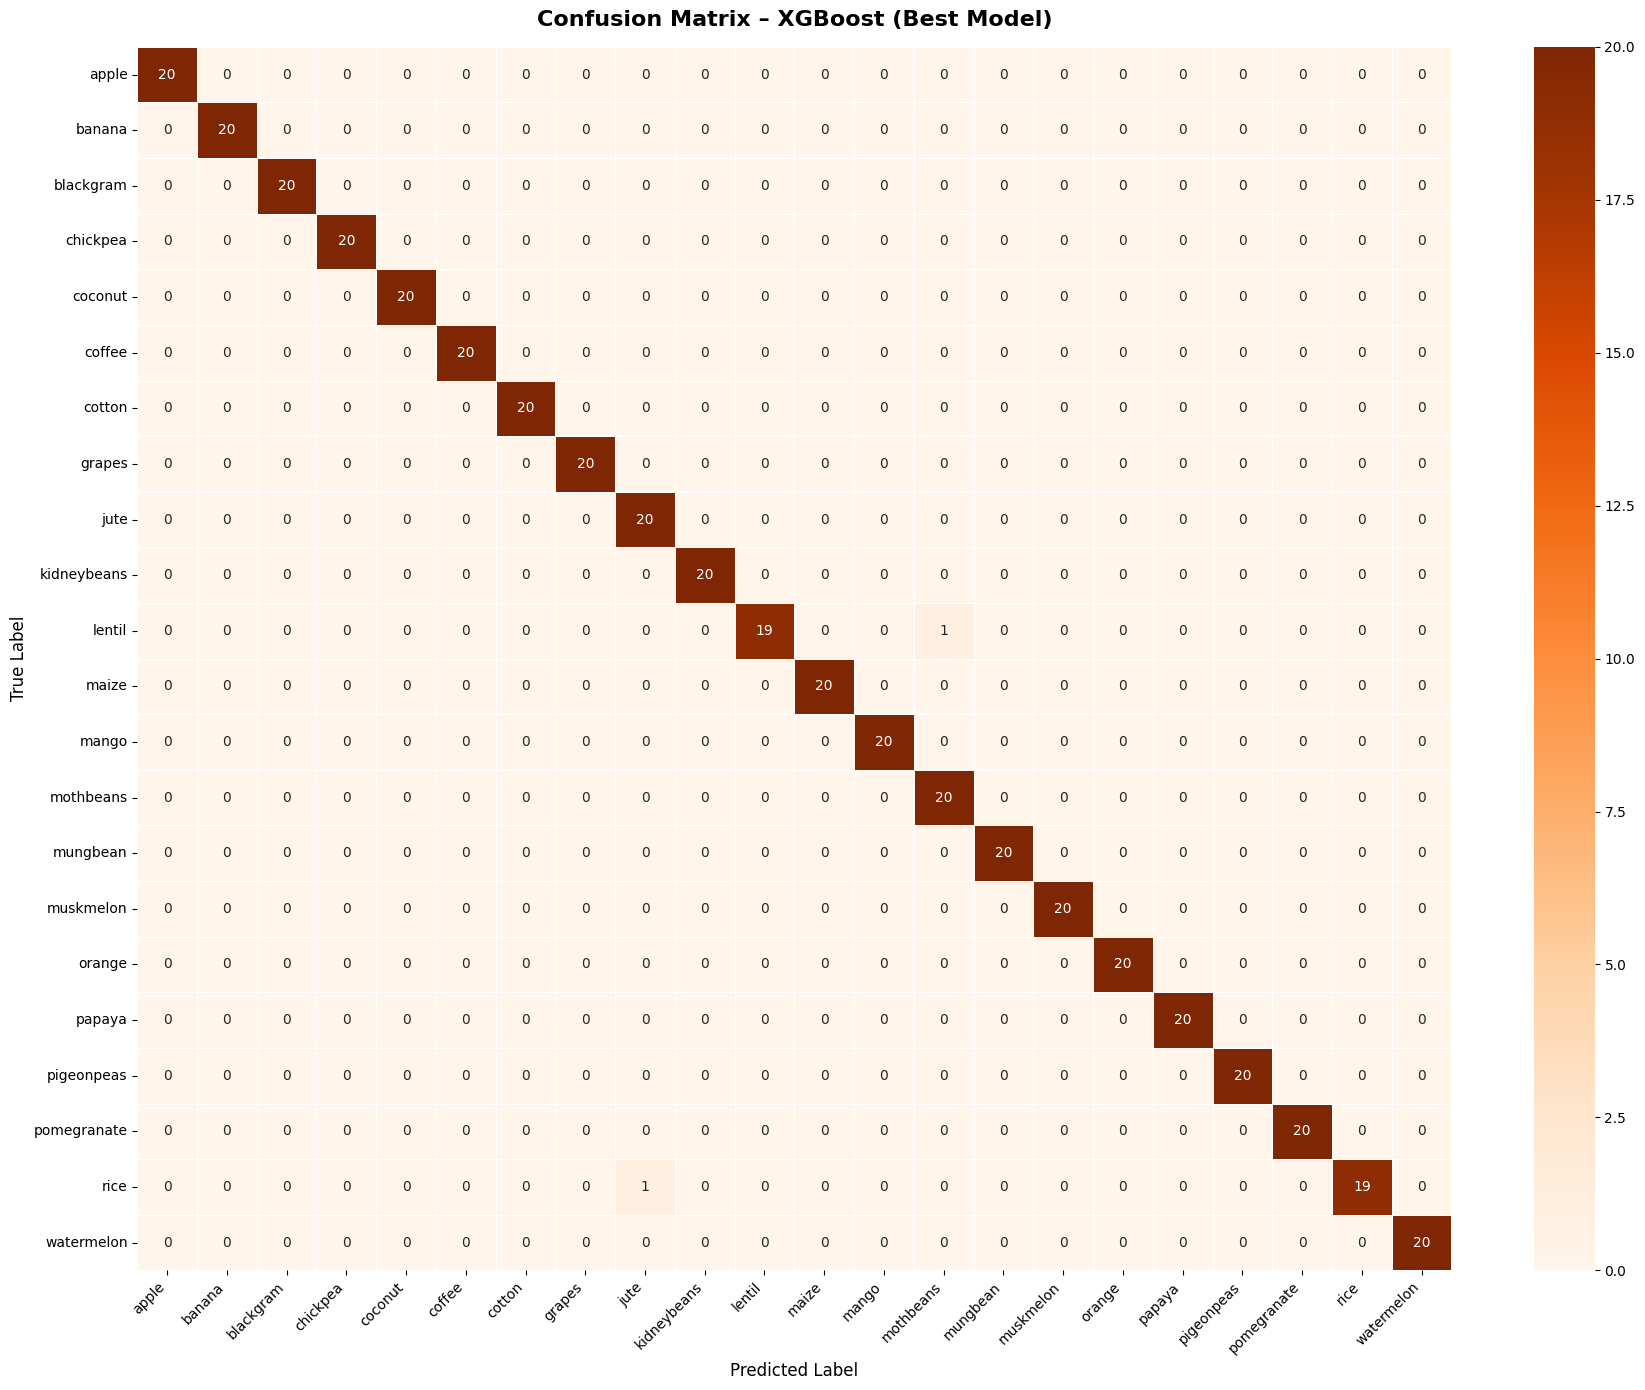

In [19]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 14))
sns.heatmap(
    conf_matrix,
    annot=True, fmt='d',
    cmap='Oranges',
    xticklabels=label_names,
    yticklabels=label_names,
    linewidths=0.5,
)
plt.title('Confusion Matrix – XGBoost (Best Model)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## **Feature Importance**

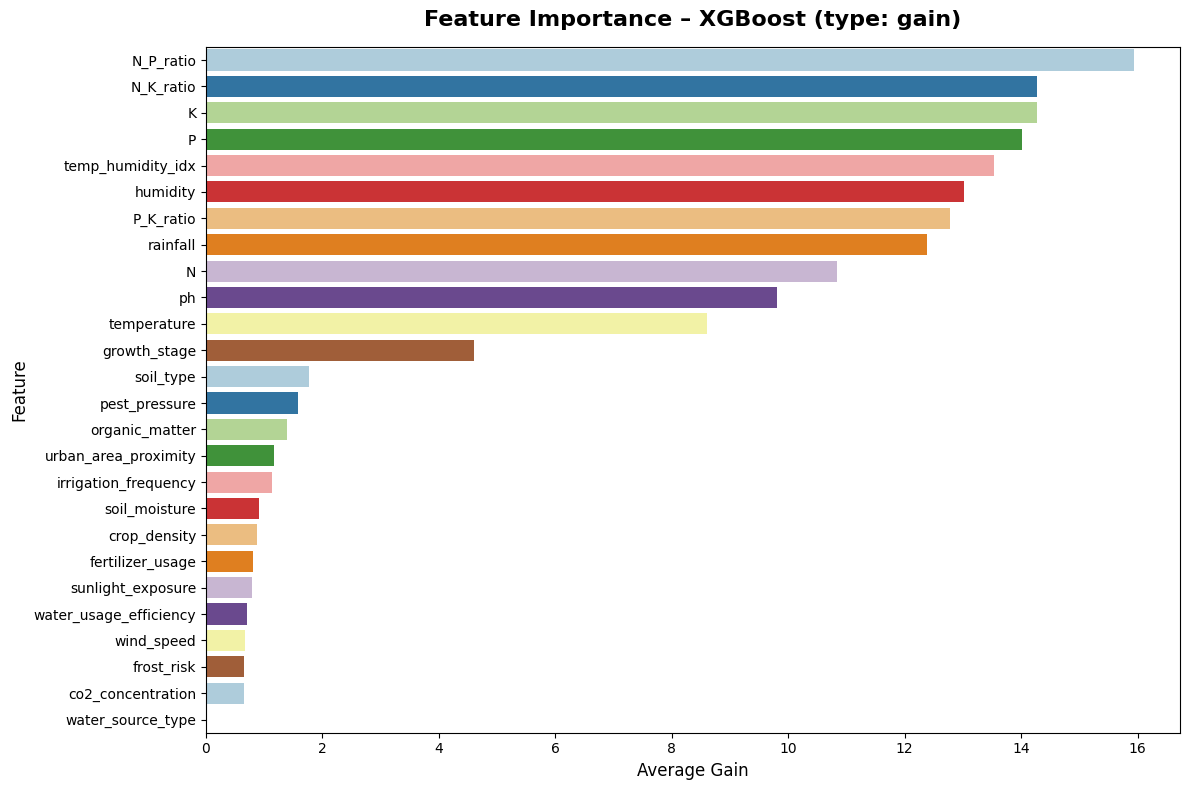


Top 10 fitur paling penting:
          feature  importance
        N_P_ratio   15.931152
        N_K_ratio   14.279115
                K   14.268754
                P   14.022445
temp_humidity_idx   13.530971
         humidity   13.010232
        P_K_ratio   12.774140
         rainfall   12.388494
                N   10.840350
               ph    9.800139


In [20]:
importance_scores = best_xgb.get_booster().get_score(importance_type='gain')

feature_importance_df = pd.DataFrame(
    list(importance_scores.items()),
    columns=['feature', 'importance']
).sort_values('importance', ascending=False)

all_features = pd.DataFrame({'feature': X_train.columns})
feature_importance_df = all_features.merge(feature_importance_df, on='feature', how='left').fillna(0)
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_importance_df,
    x='importance', y='feature',
    palette='Paired', hue='feature', legend=False
)
plt.title('Feature Importance – XGBoost (type: gain)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Gain', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print('\nTop 10 fitur paling penting:')
print(feature_importance_df.head(10).to_string(index=False))

## **Simpan Model**

In [21]:
model_dir      = '../../models'
xgb_model_path = os.path.join(model_dir, 'xgboost_best.pkl')

os.makedirs(model_dir, exist_ok=True)
joblib.dump(best_xgb, xgb_model_path)

xgb_json_path = os.path.join(model_dir, 'xgboost_best.json')
best_xgb.get_booster().save_model(xgb_json_path)

print('Model tersimpan di:')
print(f'  {os.path.abspath(xgb_model_path)}  (joblib)')
print(f'  {os.path.abspath(xgb_json_path)}   (native XGBoost)')
test_sample             = X_test.iloc[[7]]
predicted_label_encoded = best_xgb.predict(test_sample)[0]
predicted_probabilities = best_xgb.predict_proba(test_sample)[0]

top3_idx              = np.argsort(predicted_probabilities)[::-1][:3]
top3_crop_predictions = [(label_names[i], predicted_probabilities[i]) for i in top3_idx]

print(f'\nContoh prediksi:')
print(f'  Label asli   : {label_names[y_test.iloc[7]]}')
print(f'  Prediksi     : {label_names[predicted_label_encoded]}')
print('  Top-3 probabilitas:')
for crop, prob in top3_crop_predictions:
    print(f'    {crop:<15}: {prob*100:.2f}%')

Model tersimpan di:
  /Users/anargyaisadhimaheswara/Documents/Semester6/Daming/project-daming/models/xgboost_best.pkl  (joblib)
  /Users/anargyaisadhimaheswara/Documents/Semester6/Daming/project-daming/models/xgboost_best.json   (native XGBoost)

Contoh prediksi:
  Label asli   : blackgram
  Prediksi     : blackgram
  Top-3 probabilitas:
    blackgram      : 97.08%
    lentil         : 0.98%
    pigeonpeas     : 0.34%
